### 42028 : Deep Learning and CNN
### Assignment 2

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To perform Image Classification using baseline CNN architectures

### Contents
1. Section 1 : Loading Dataset
2. Section 2 : Exploratory Data Analysis
3. Section 3 : Data Augmentation
4. Section 4 : Baseline VGG16 Modelling
5. Section 5 : Baseline ResNet18 Modelling

### Drive Mounting

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# !unzip ./drive/MyDrive/UTS_Academics/42904_Deep_Learning/Assignment_2/student_25675238.zip -d ./drive/MyDrive/UTS_Academics/42904_Deep_Learning/Assignment_2/

### System GPU Checks

In [2]:
#Check GPU
!nvidia-smi

Tue May 12 23:35:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   31C    P0             31W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!find / -type f -name "libdevice.10.bc" 2>/dev/null

/opt/conda/lib/python3.12/site-packages/triton/backends/nvidia/lib/libdevice.10.bc


/opt/conda/nvvm/libdevice/libdevice.10.bc


### Library Imports

In [4]:
!pip install opencv-python --quiet

In [5]:
!pip install pydot

In [6]:
!pip install silence-tensorflow

In [7]:
!pip install numpy

In [69]:
# Importing required libraries and setting global variables
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pydot
import random
import seaborn as sns
import tensorflow as tf
import keras

In [9]:
dataset_path = './25675238/Image_Classification/dataset'
data_files_path = './data_files/Image_Classification'
results_files_path = './results_and_models'
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/opt/conda'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [77]:
from datetime import datetime
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score
from sklearn.preprocessing import LabelEncoder
from keras import models
from keras import layers
from keras import optimizers
from keras.models import load_model
from keras.applications import VGG16, ResNet50
from keras.applications.vgg16 import preprocess_input
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from silence_tensorflow import silence_tensorflow

In [11]:
tf.get_logger().setLevel('ERROR')
silence_tensorflow()

### Section 1 : Loading Dataset

In [ ]:
#Renaming folder names to lowercase # This operation is for one-time execution
# for folder in classes:
#     folder_path = os.path.join(dataset_path, folder)
#     new_path = os.path.join(dataset_path, folder.lower())
#     os.rename(folder_path, new_path)

In [12]:
classes = os.listdir(dataset_path)

In [13]:
classes

['borzoi',
 'toy_terrier',
 'wire-haired_fox_terrier',
 'schipperke',
 'chihuahua',
 'sussex_spaniel',
 'bernese_mountain_dog',
 'norwegian_elkhound',
 'german_short-haired_pointer',
 'brittany_spaniel']

In [13]:
!find ./25675238/Image_Classification/dataset -maxdepth 2 -type f -iname "*.jpg" -printf '%h\n' | sort | uniq -c | awk -F'/' '{printf "%-30s : %s images\n", $NF, $1}'

bernese_mountain_dog           :     218 . images
borzoi                         :     151 . images
brittany_spaniel               :     152 . images
chihuahua                      :     152 . images
german_short-haired_pointer    :     152 . images
norwegian_elkhound             :     196 . images
schipperke                     :     154 . images
sussex_spaniel                 :     151 . images
toy_terrier                    :     172 . images
wire-haired_fox_terrier        :     157 . images


In [14]:
!find ./25675238/Image_Classification/dataset -maxdepth 2 -type f -iname "*.jpg" | wc -l | awk '{printf "Total number of images : %s", $1}'

Total number of images : 1655

### Section 2 : Exploratory Data Analysis

*In this section, we explore the characteristics of this dataset. We will use OpenCV library to access and examine the images*

*As shown in the previous sections, the dataset contains of 10 classes of dog images.*

*Each class consists of different number of images, bringing the total number of images to 1655.*

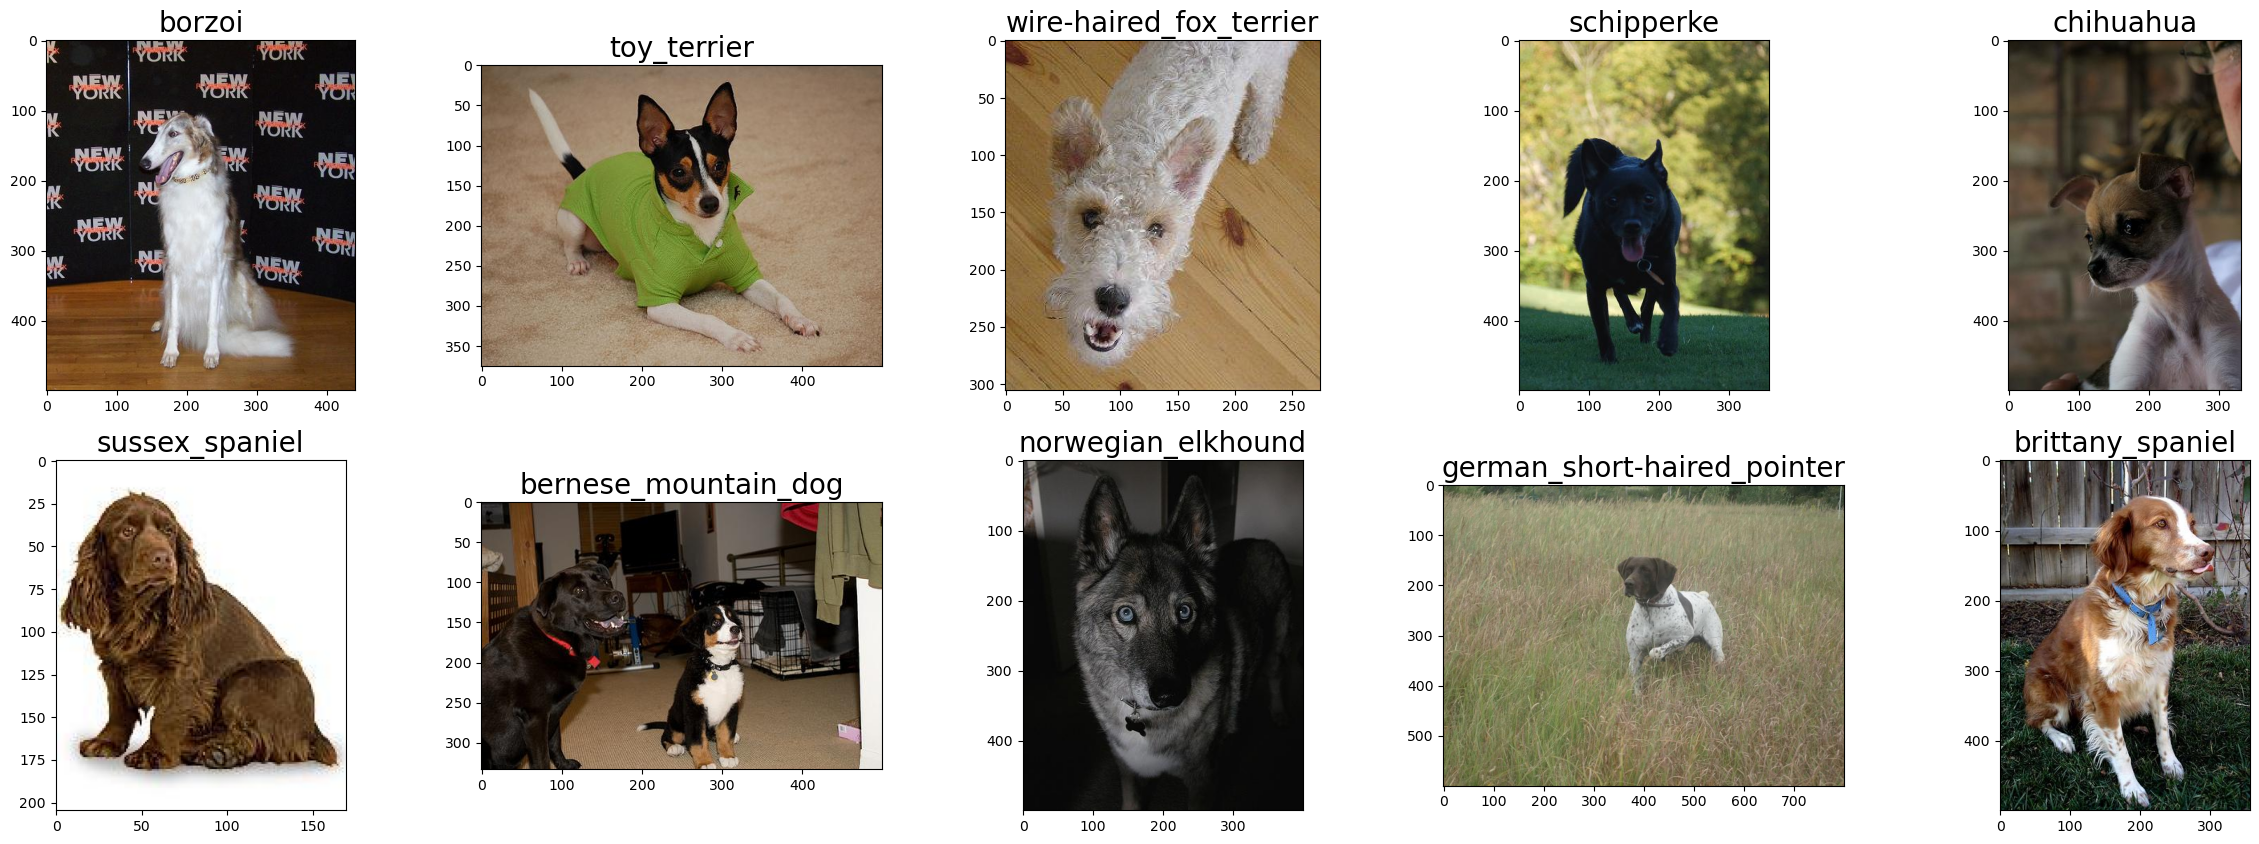

In [14]:
#Analysing images from every class

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(30,10))
class_idx = 0
for i in range(2):
    for j in range(5):
        folder_path = dataset_path + "/" + classes[class_idx]
        images_path = os.listdir(folder_path)
        img_idx = random.randint(0, len(images_path) - 1) # Showing a random image for the same class on every run
        img = cv2.imread(folder_path + "/" + images_path[img_idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i,j].imshow(img)
        axes[i,j].set_title(classes[class_idx], fontsize=20)
        class_idx += 1
plt.show()

In [15]:
#Printing image shape
image = cv2.imread(dataset_path + '/bernese_mountain_dog/01.jpg')
print("Image dimensions :", image.shape)
print("Image data type :", image.dtype)
print("Image width :", image.shape[0])
print("Image length :", image.shape[1])

Image dimensions : (333, 500, 3)
Image data type : uint8
Image width : 333
Image length : 500


*It can be observed that the images have 3 (RGB) channels.*

All images analysed for class :  borzoi


All images analysed for class :  toy_terrier
All images analysed for class :  wire-haired_fox_terrier


All images analysed for class :  schipperke


All images analysed for class :  chihuahua


All images analysed for class :  sussex_spaniel


All images analysed for class :  bernese_mountain_dog


All images analysed for class :  norwegian_elkhound


All images analysed for class :  german_short-haired_pointer


All images analysed for class :  brittany_spaniel


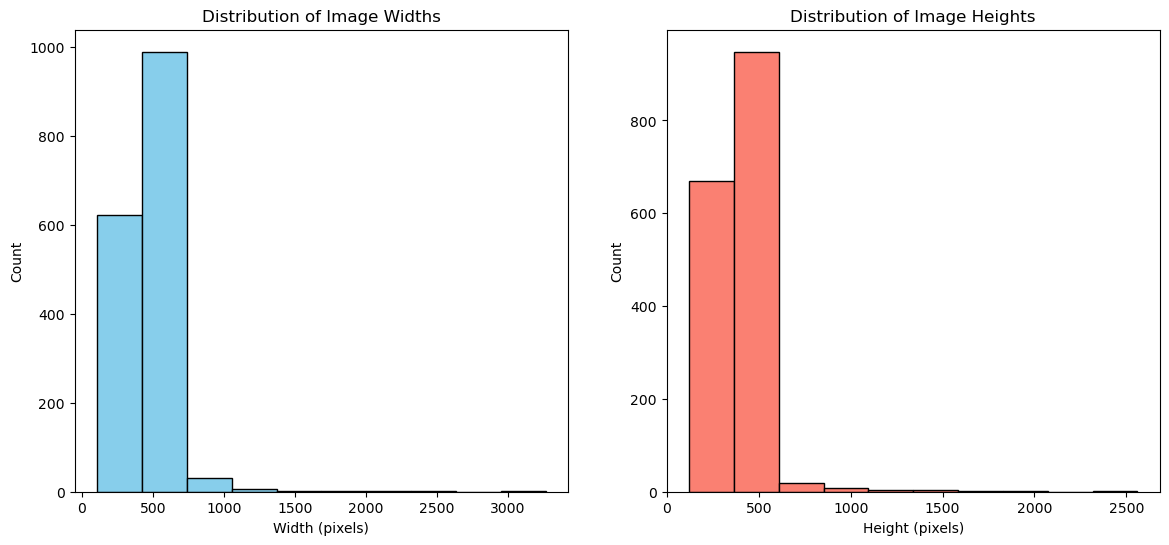

In [16]:
#Gathering image widths and heights and observing their distribution
widths = []
heights = []

#While traversing all images and labels, store them into separate arrays
#The images array will contain the image while the labels array will contain the class name as the label for that image
images = []
labels = []

for class_name in classes:
    folder_path = dataset_path + "/" + class_name
    images_path = os.listdir(folder_path)
    for i in images_path:
        img_path = folder_path + "/" + i
        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

        images.append(img)
        labels.append(class_name)
    print("All images analysed for class : ", class_name)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Width Histogram
ax1.hist(widths, bins=10, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Image Widths')
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Count')

# Height Histogram
ax2.hist(heights, bins=10, color='salmon', edgecolor='black')
ax2.set_title('Distribution of Image Heights')
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Count')

plt.show()

*It can be observed that all images belonging to the 10 classes have varied heights and widths which requires further processing before ingesting them into the CNN model.*

*From the obove mentioned distribtion it can be seen that maximum images have heights and widths around 500px, which is a significantly larger image for CNN training*

In [18]:
#Writing the raw images and labels to .npy files for reuse
images_np_array = np.array(images, dtype=object)
labels_np_array = np.array(labels, dtype=object)

np.savez(data_files_path + '/original_images.npz', images_np_array)
np.savez(data_files_path + '/original_labels.npz', labels_np_array)

### Section 3 : Original data loading and Augmentation

In [17]:
# Loading the preprocessed images from npz files
with np.load(data_files_path + '/original_images.npz', allow_pickle=True) as data:
    images = list(data['arr_0'])

In [18]:
# Loading the original labels from the npz files
with np.load(data_files_path + '/original_labels.npz', allow_pickle=True) as data:
    labels = list(data['arr_0'])

In [19]:
# Encoding labels
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

In [20]:
# Creating training and testing sets
images_train, images_test, labels_train, labels_test = train_test_split(
    images, encoded_labels,
    test_size=0.15,
    train_size=0.85,
    random_state=25675238 #Using student ID as random seed
)

In [21]:
# Creating validation set
images_valid = images_train[:250]
labels_valid = labels_train[:250]

images_train = images_train[250:]
labels_train = labels_train[250:]

*The dataset is initially split into 85% training set and 15% testing set.*

*The training set is split into another 70% and 15% validation set*

In [22]:
# Image resizing
# The images of variable length are resized to 224x224 to standardize the input to the baseline models
resize_train_image = []
resize_valid_image = []
resize_test_image = []

for img in images_train:
    rsz_img = cv2.resize(img, (224, 224))
    resize_train_image.append(rsz_img)
for img in images_valid:
    rsz_img = cv2.resize(img, (224, 224))
    resize_valid_image.append(rsz_img)
for img in images_test:
    rsz_img = cv2.resize(img, (224, 224))
    resize_test_image.append(rsz_img)

In [48]:
# Converting list of images to numpy array for model training
images_train = np.asarray(resize_train_image).astype('float32')
images_valid = np.asarray(resize_valid_image).astype('float32')
images_test = np.asarray(resize_test_image).astype('float32')

In [24]:
labels_train = np.asarray(labels_train)
labels_valid = np.asarray(labels_valid)
labels_test = np.asarray(labels_test)

In [25]:
classes = os.listdir(dataset_path)
classes

['borzoi',
 'toy_terrier',
 'wire-haired_fox_terrier',
 'schipperke',
 'chihuahua',
 'sussex_spaniel',
 'bernese_mountain_dog',
 'norwegian_elkhound',
 'german_short-haired_pointer',
 'brittany_spaniel']

In [26]:
# Creating augmentation samples for visualization
augmented_samples_path = './augmented_samples'

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

for name in classes:
    i = 0
    for batch in datagen.flow(
        images_train,
        labels_train,
        batch_size=1,
        save_to_dir=augmented_samples_path, 
        save_prefix=f'aug_{name}', 
        save_format='jpeg'
    ):
        i += 1
        if i >= 2:
            break 
    print(f"Created 2 samples for {name}")

# Cleanup augmented samples
!rm -r ./augmented_samples/.ipynb_checkpoints

Created 2 samples for borzoi
Created 2 samples for toy_terrier
Created 2 samples for wire-haired_fox_terrier
Created 2 samples for schipperke
Created 2 samples for chihuahua
Created 2 samples for sussex_spaniel
Created 2 samples for bernese_mountain_dog
Created 2 samples for norwegian_elkhound
Created 2 samples for german_short-haired_pointer
Created 2 samples for brittany_spaniel


rm: cannot remove './augmented_samples/.ipynb_checkpoints': No such file or directory


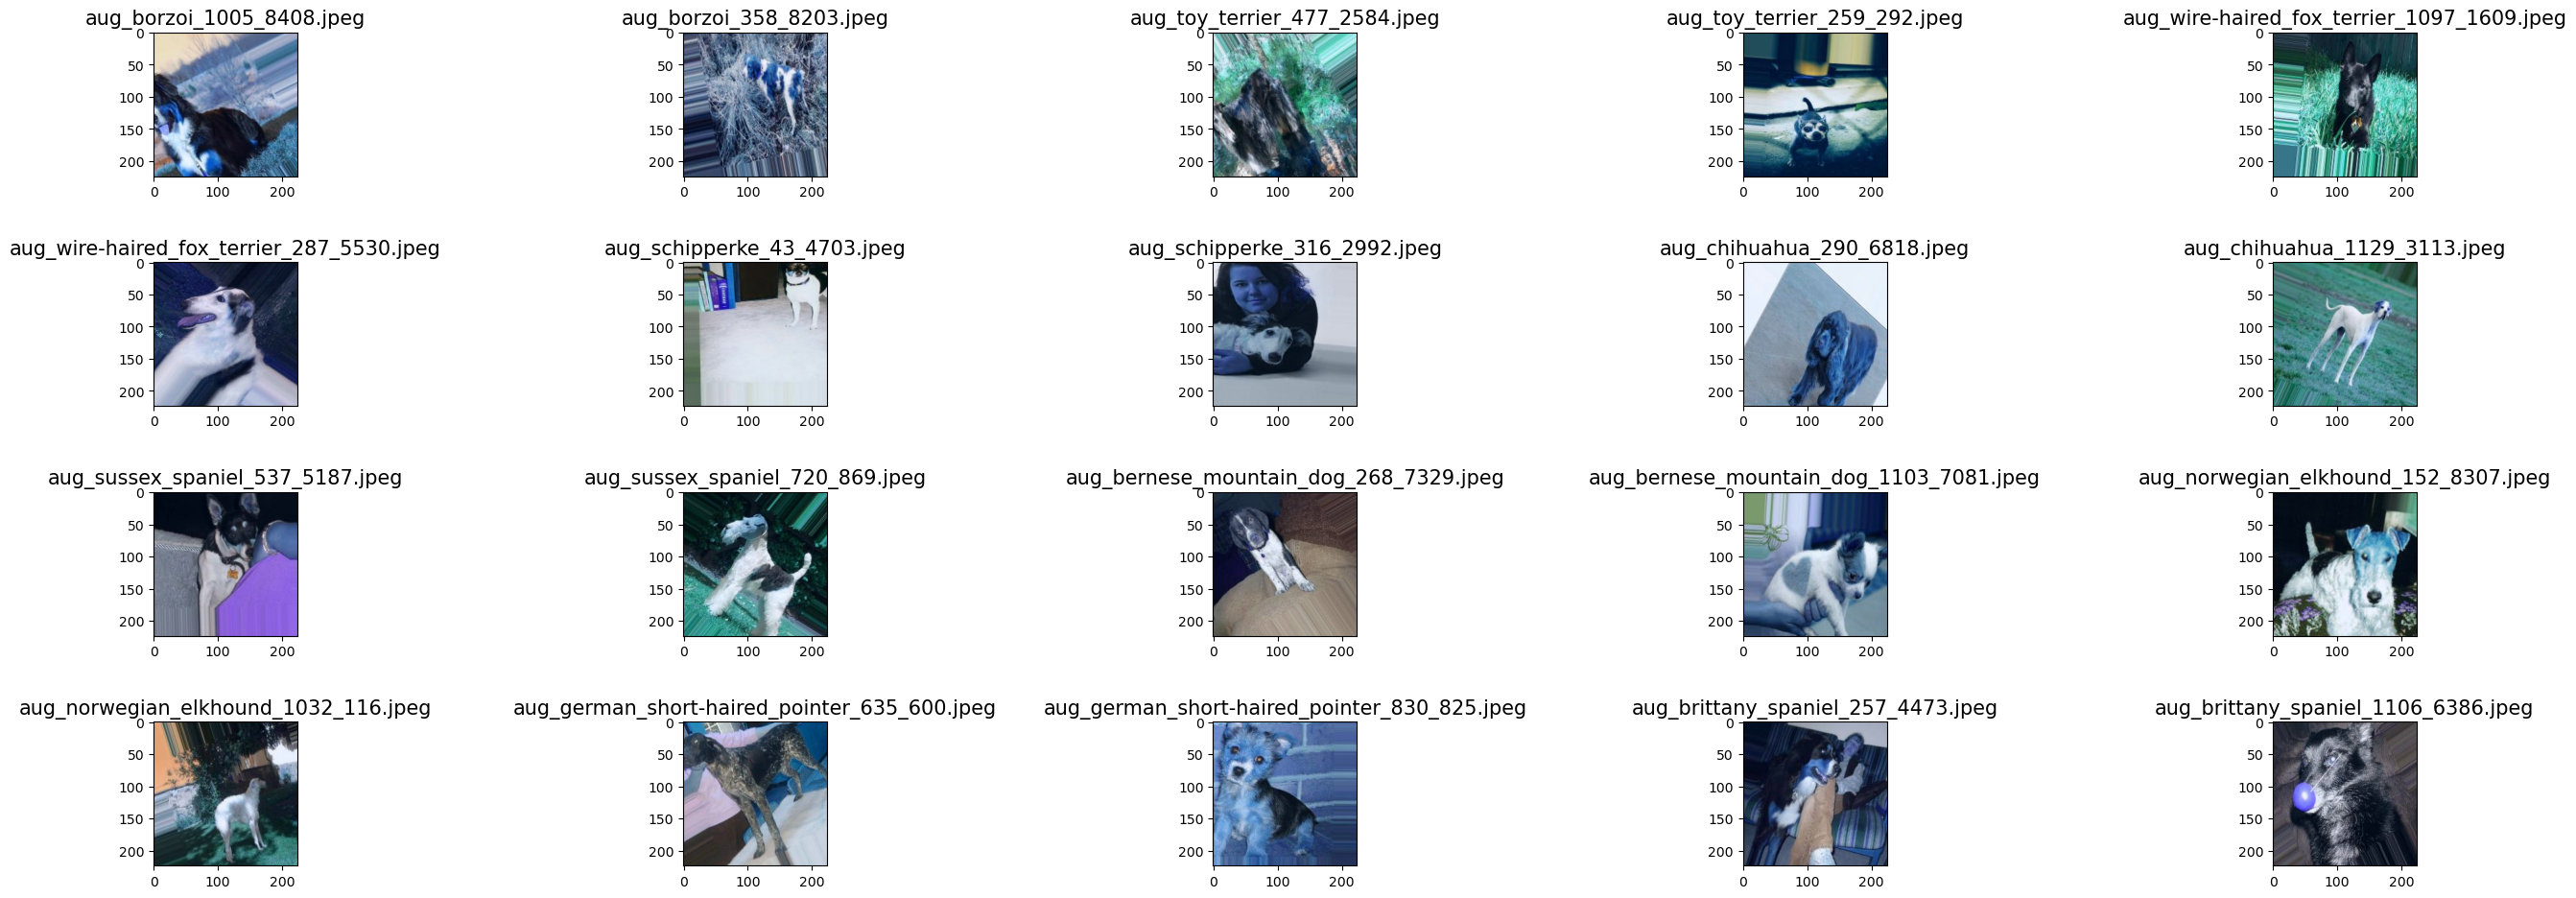

In [27]:
# Analysing augmented images from every class

fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(30,10))
augmented_images = os.listdir(augmented_samples_path)
aug_img_idx = 0
for i in range(4):
    for j in range(5):
        img = cv2.imread(augmented_samples_path + "/" + augmented_images[aug_img_idx])
        axes[i,j].imshow(img)
        axes[i,j].set_title(augmented_images[aug_img_idx], fontsize=15)
        aug_img_idx += 1
plt.tight_layout(pad=3.0)
plt.show()

In [29]:
# Cleanup augmented samples
!rm -rf ./augmented_samples/*

In [28]:
train_datagen = ImageDataGenerator(
      preprocessing_function=preprocess_input,
      rotation_range=20,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest'
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow(
    images_train,
    labels_train,
    batch_size=36,
    seed=25675238
)

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow(
    images_valid,
    labels_valid,
    batch_size=36,
    seed=25675238
)

### Section 3 : Baseline CNN Modelling (VGG16)

In [29]:
# Using VGG16 model with pretrained weights
conv_base = VGG16(weights='imagenet',include_top=False, input_shape=(224, 224, 3))
model = models.Sequential()
model.add(conv_base)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

I0000 00:00:1778629058.932951    5276 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [30]:
# Freezing the convolutional base of the VGG16 model
for layer in conv_base.layers[:-4]: 
    layer.trainable = False

In [31]:
# Model compilation
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### VGG16 Model Fit

In [78]:
# Checkpointing model weights as per progress
filepath = './results_and_models/baseline_vgg_weights/weights_modified.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    save_freq='epoch'
)

In [33]:
# CSV logger for adding results to a .csv file
csv_logger = CSVLogger('./results_and_models/baseline_vgg_logs.csv', append=False, separator=',')

In [34]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.2,   # Drop LR by 80%
    patience=5,   # Wait 5 epochs before dropping
    min_lr=1e-7
)

In [35]:
early_stop = EarlyStopping(
    monitor='val_accuracy',   # Or 'val_loss'
    patience=10,              # How many epochs to wait for an improvement
    verbose=1,                # Notifies you when it stops
    restore_best_weights=True # Rolls back to the "best" version of the model
)

In [36]:
# Train the model
history = model.fit(
    train_generator,
    epochs=100,
    steps_per_epoch = 32,
    validation_data=validation_generator,
    validation_steps=8,
    callbacks = [checkpoint, csv_logger, reduce_lr, early_stop],
    verbose=0
    )

I0000 00:00:1778629082.392118    5496 service.cc:152] XLA service 0x7fe729550c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778629082.392148    5496 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-05-12 23:38:02.449302: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1778629082.859659    5496 cuda_dnn.cc:529] Loaded cuDNN version 91002


2026-05-12 23:38:03.389060: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.39 = (f32[36,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,3,224,224]{3,2,1,0} %bitcast.4717, f32[64,3,3,3]{3,2,1,0} %bitcast.4724, f32[64]{0} %bitcast.4726), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block1_conv1_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-05-12 23:38:03.553459: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted

2026-05-12 23:38:06.075006: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.41 = (f32[36,128,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,64,112,112]{3,2,1,0} %bitcast.4747, f32[128,64,3,3]{3,2,1,0} %bitcast.4754, f32[128]{0} %bitcast.4756), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block2_conv1_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}


2026-05-12 23:38:07.149511: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.42 = (f32[36,128,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,128,112,112]{3,2,1,0} %bitcast.4761, f32[128,128,3,3]{3,2,1,0} %bitcast.4768, f32[128]{0} %bitcast.4770), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block2_conv2_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}


...


Epoch 77: val_accuracy did not improve from 0.89200



Epoch 78: val_accuracy did not improve from 0.89200



Epoch 79: val_accuracy did not improve from 0.89200


Epoch 79: early stopping


Restoring model weights from the end of the best epoch: 69.


In [37]:
model_save_path = results_files_path + '/baseline_models/'
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = model_save_path + f"vgg16_model_{timestamp}.keras"
model.save(model_name)

#### VGG16 Model Results

In [44]:
# Retrieving the latest model
saved_models = os.listdir(model_save_path)
saved_models.sort(reverse=True)
latest_model_path = model_save_path + saved_models[0]
model_vgg = load_model(latest_model_path)

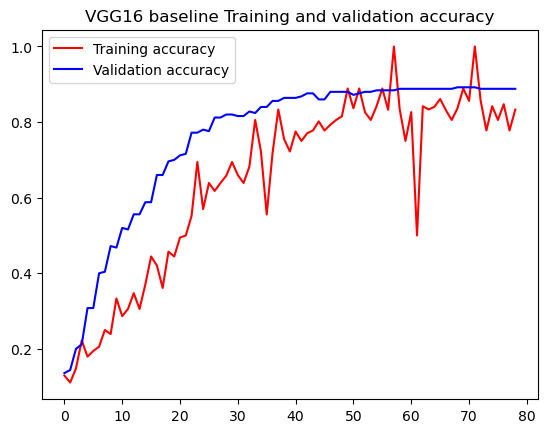

<Figure size 640x480 with 0 Axes>

In [45]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('VGG16 baseline Training and validation accuracy')
plt.legend()
plt.show()
plt.savefig('./results_and_models/VGG16_Baseline_Accuracy.png')

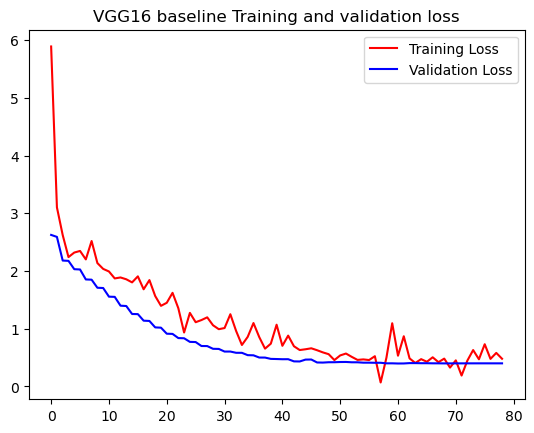

In [46]:
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('VGG16 baseline Training and validation loss')
plt.legend()
plt.savefig('./results_and_models/VGG16_Baseline_Loss.png')

#### VGG16 Model Predictions

In [52]:
model_vgg_predictions = model_vgg.predict(images_test)

1/8 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step

2/8 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step

3/8 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step

4/8 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step

5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step

6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step


In [60]:
lables_vgg_predict = np.argmax(model_vgg_predictions, axis=1)

In [59]:
len(labels_test)

249

In [61]:
len(lables_vgg_predict)

249

In [71]:
# Reversing the encoding
labels_test_names = encoder.inverse_transform(labels_test)
labels_vgg_pred_names = encoder.inverse_transform(lables_vgg_predict)

In [73]:
# Calculate Accuracy
accuracy = accuracy_score(labels_test_names, labels_vgg_pred_names)
print(f"Accuracy: {accuracy:.4f}")

# Detailed breakdown
print(classification_report(labels_test_names, labels_vgg_pred_names))

Accuracy: 0.8072
                             precision    recall  f1-score   support

       bernese_mountain_dog       0.92      0.77      0.84        30
                     borzoi       0.72      0.96      0.82        24
           brittany_spaniel       0.78      0.64      0.70        22
                  chihuahua       0.67      0.44      0.53        18
german_short-haired_pointer       0.76      0.76      0.76        25
         norwegian_elkhound       0.87      0.89      0.88        37
                 schipperke       1.00      0.79      0.88        19
             sussex_spaniel       0.86      0.95      0.90        20
                toy_terrier       0.76      0.84      0.80        31
    wire-haired_fox_terrier       0.75      0.91      0.82        23

                   accuracy                           0.81       249
                  macro avg       0.81      0.79      0.79       249
               weighted avg       0.81      0.81      0.80       249



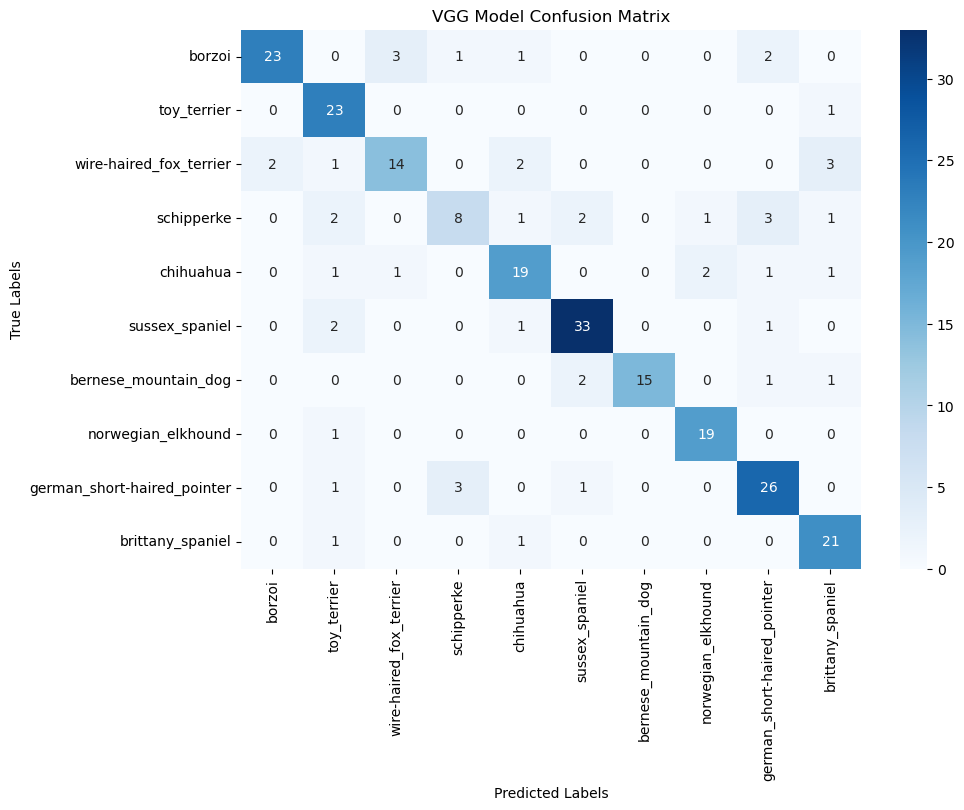

In [76]:
#Plotting confusion matrix
cm = confusion_matrix(labels_test_names, labels_vgg_pred_names)

# 2. Plot using Seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('VGG Model Confusion Matrix')
plt.show()

### Section 4 : Baseline CNN Modelling (ResNet50) on Original Data

In [69]:
# Using ResNet50 model with pretrained weights
conv_base_res = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_res = models.Sequential()
model_res.add(conv_base_res)
model_res.add(layers.Flatten())
model_res.add(layers.Dense(10, activation='softmax'))

I0000 00:00:1778232857.556734    2300 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [70]:
# for layer in conv_base_res.layers:
#     layer.trainable = False

In [71]:
model_res.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
filepath = './results_and_models/baseline_resnet_weights/weights_modified.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    save_freq='epoch'
)

#### ResNet50 Model Fit

In [73]:
# Train the model
history = model_res.fit(
    train_generator,
    epochs=100,
    steps_per_epoch = 32,
    validation_data=validation_generator,
    validation_steps=8,
    callbacks = [checkpoint],
    verbose=2
    )

Epoch 1/100


I0000 00:00:1778232905.580191    4657 service.cc:148] XLA service 0x7f87e8002950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778232905.580230    4657 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-05-08 09:35:06.775132: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778232910.107977    4657 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-08 09:35:12.411980: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[36,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activati


Epoch 1: val_accuracy improved from None to 0.08400, saving model to ./results_and_models/baseline_resnet_weights/weights_modified.01-4.45.keras


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 - 96s - 3s/step - accuracy: 0.5857 - loss: 1.6830 - val_accuracy: 0.0840 - val_loss: 4.4451
Epoch 2/100

Epoch 2: val_accuracy did not improve from 0.08400
32/32 - 1s - 30ms/step - accuracy: 0.7500 - loss: 0.6051 - val_accuracy: 0.0840 - val_loss: 4.5314
Epoch 3/100

Epoch 3: val_accuracy did not improve from 0.08400
32/32 - 13s - 394ms/step - accuracy: 0.8848 - loss: 0.4303 - val_accuracy: 0.0840 - val_loss: 3.2681
Epoch 4/100

Epoch 4: val_accuracy improved from 0.08400 to 0.08800, saving model to ./results_and_models/baseline_resnet_weights/weights_modified.04-3.23.keras
32/32 - 2s - 68ms/step - accuracy: 0.8889 - loss: 0.4723 - val_accuracy: 0.0880 - val_loss: 3.2266
Epoch 5/100

Epoch 5: val_accuracy improved from 0.08800 to 0.09200, saving model to ./results_and_models/baseline_resnet_weights/weights_modified.05-5.72.keras
32/32 - 14s - 431ms/step - accuracy: 0.8955 - loss: 0.4118 - val_accuracy: 0.0920 - val_loss: 5.7239
Epoch 6/100

Epoch 6: val_accuracy did not improve f

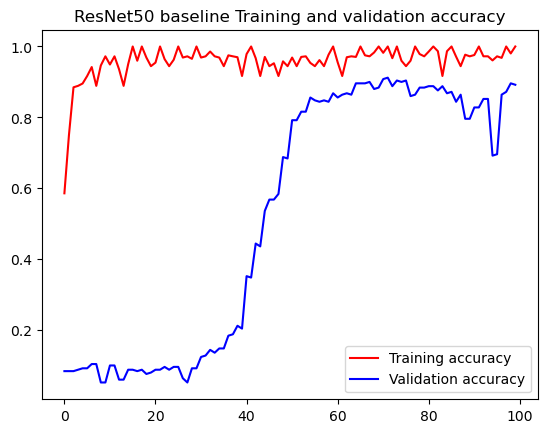

<Figure size 640x480 with 0 Axes>

In [77]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('ResNet50 baseline Training and validation accuracy')
plt.legend()
plt.show()
plt.savefig('./results_and_models/ResNet50_Baseline_Accuracy.png')

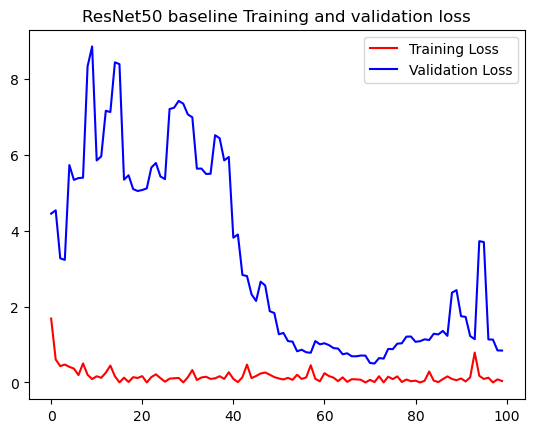

In [78]:
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('ResNet50 baseline Training and validation loss')
plt.legend()
plt.savefig('./results_and_models/ResNet50_Baseline_Loss.png')